L = 2, N = 1, dim = 2
init = (1, 0), target = (0, 1)
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
final norm = 0.999999389227375
Fitted Rabi period  T_Rabi = 60.7903 ms (+/- 0.0000 ms)
Effective Rabi freq Omega_eff/2pi = 16.45 Hz
Fitted amplitude    A = 0.991


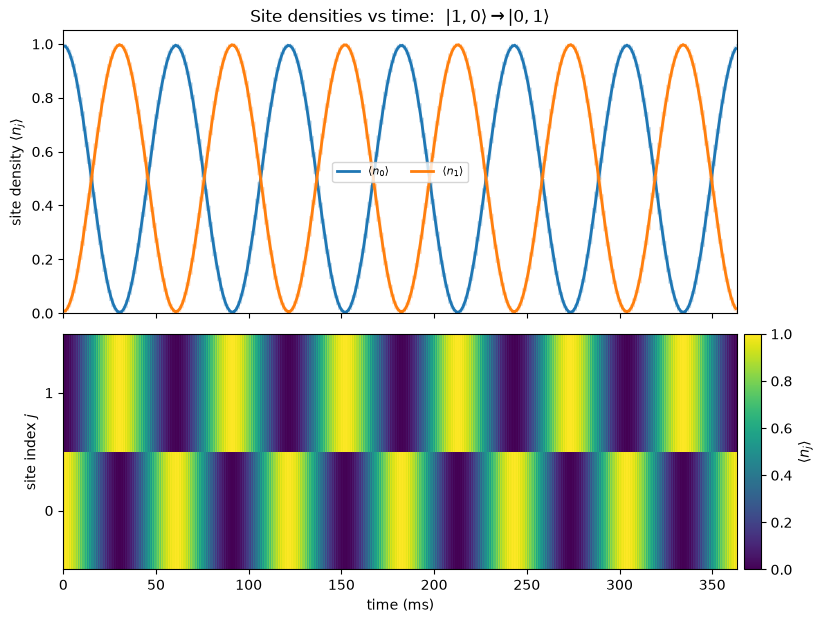

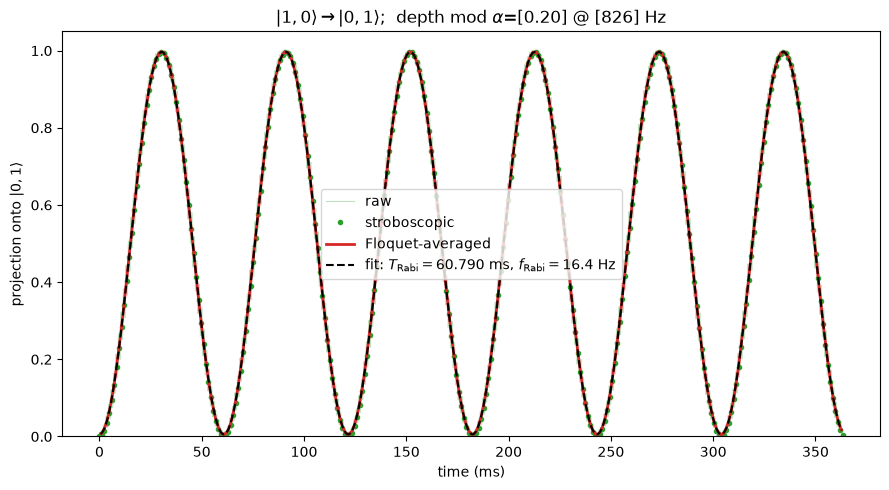

In [13]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# =============================================================
# RUN OPTIONS
# =============================================================
SHOW_DIAGNOSTIC = False
SHOW_SITE_DENSITIES = True   # plot <n_j>(t) across the L sites before the 1D curve

# Pulsed-spectroscopy scan: after fitting T_Rabi on resonance, hold the pulse
# duration fixed at T_Rabi/2 (a pi-pulse) and scan the drive frequency.
# The resulting lineshape is the Rabi-pulse profile (sinc-like x Lorentzian).
DO_PULSE_SCAN   = False
PULSE_SPAN_HZ   = 120.0     # +/- frequency range around the nominal drive
PULSE_N_POINTS  = 61
PULSE_SAMPLES_PER_PERIOD = 20   # for Floquet-averaging the endpoint population

# =============================================================
# INITIAL AND TARGET FOCK STATES
# =============================================================
state_init   = [1, 0]
state_target = [0, 1]

state_init   = list(state_init)
state_target = list(state_target)
if len(state_init) != len(state_target):
    raise ValueError("state_init and state_target must have the same length (L): "
                     "got %d and %d" % (len(state_init), len(state_target)))
L = len(state_init)
N = sum(state_init)
if sum(state_target) != N:
    raise ValueError("state_init and state_target must have the same particle "
                     "number N. init has N=%d, target has N=%d." % (N, sum(state_target)))

# =============================================================
# LATTICE DEPTH -> TUNNELING CONVERTER
# =============================================================
J_OUTPUT_UNITS = "Hz"
E_R_HZ = 1.0

def V_to_J(V):
    V = np.asarray(V, dtype=float)
    a = 284.4; b = -0.2922; c = 30.69; d = -0.1304   # Er in, Hz out
    return a * np.exp(b * V) + c * np.exp(d * V)

# --- static lattice depth ----
V0 = 0.75 * 10.0           # static lattice depth (Er)

twopi = 2.0 * np.pi
def J_angular(V):
    Jval = V_to_J(V)
    if J_OUTPUT_UNITS == "Hz":      return twopi * Jval
    elif J_OUTPUT_UNITS == "angular": return Jval
    elif J_OUTPUT_UNITS == "Er":    return twopi * E_R_HZ * Jval
    else: raise ValueError("J_OUTPUT_UNITS must be 'Hz', 'angular', or 'Er'")

# -----------------------------
# Other physical parameters
# -----------------------------
U_hz     = 280.0
Delta_hz = 820.0

# --- MULTI-TONE DEPTH MODULATION ---------------------------------------------

if np.sum(state_init) == 1:
    alpha        = [0.2]
    f_drive_list = [Delta_hz+5.6]
elif np.sum(state_init) == 2:
    alpha        = [0.2, 0.2]
    f_drive_list = [Delta_hz - U_hz, Delta_hz + U_hz]
# -----------------------------------------------------------------------------
alpha        = np.atleast_1d(np.asarray(alpha, dtype=float))
f_drive_list = np.atleast_1d(np.asarray(f_drive_list, dtype=float))
if alpha.shape != f_drive_list.shape:
    raise ValueError("alpha and f_drive_list must have the same length.")

U     = twopi * U_hz
Delta = twopi * Delta_hz
omega = twopi * f_drive_list

N_PERIODS_PER_RABI = 100
f_ref_hz = f_drive_list.min()

# -----------------------------
# Fixed-N basis
# -----------------------------
def generate_basis(L, N):
    return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
            if sum(occ) == N]
basis = generate_basis(L, N)
index = {s: i for i, s in enumerate(basis)}
dim   = len(basis)
if tuple(state_init) not in index or tuple(state_target) not in index:
    raise ValueError("init/target state not present in the N=%d basis." % N)

print("L = %d, N = %d, dim = %d" % (L, N, dim))
print("init = %s, target = %s" % (tuple(state_init), tuple(state_target)))
print("static depth V0 = %.4g Er -> J(V0) = %.4f Hz" % (V0, J_angular(V0)/twopi))

# -----------------------------
# Hamiltonian pieces
# -----------------------------
def build_diag():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        H[a, a] = 0.5 * U * np.sum(n*(n-1)) + Delta * np.sum(np.arange(L)*n)
    return H

def build_hop_unit():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        for j in range(L-1):
            if n[j] > 0:
                new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                new[j]-=1; new[j+1]+=1
                H[index[tuple(new)], a] += -amp
            if n[j+1] > 0:
                new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                new[j+1]-=1; new[j]+=1
                H[index[tuple(new)], a] += -amp
    return H

H_diag    = build_diag()
H_hop_unit = build_hop_unit()

# -----------------------------
# Per-site number operators (diagonal in the Fock basis)
# -----------------------------
site_occ = np.array([list(state) for state in basis], dtype=float)  # shape (dim, L)

def site_densities(psis):
    """Return <n_j>(t): array of shape (ntimes, L)."""
    probs = np.abs(psis)**2          # (ntimes, dim)
    return probs @ site_occ          # (ntimes, L)

# -----------------------------
# State and projector
# -----------------------------
psi0 = np.zeros(dim, dtype=complex)
psi0[index[tuple(state_init)]] = 1.0
P_target = np.zeros((dim, dim), dtype=complex)
P_target[index[tuple(state_target)], index[tuple(state_target)]] = 1.0

# -----------------------------
# Depth modulation and evolution (drive frequency overridable for the scan)
# -----------------------------
def V_of_t(t, om):
    return V0 * (1.0 + np.sum(alpha * np.cos(om * t)))

def evolve(n_periods, samples_per_period, om=None, t_end=None):
    """Evolve under the drive. om defaults to the nominal omega; if t_end is given
    it overrides n_periods*T_ref (used for fixed-duration pulses)."""
    if om is None:
        om = omega
    T_ref_local = 1.0 / (om.min() / twopi)
    if t_end is None:
        t_end = n_periods * T_ref_local
        ntimes = n_periods * samples_per_period + 1
    else:
        # choose sample count to keep ~samples_per_period per drive period
        n_per = max(1, int(round(t_end / T_ref_local)))
        ntimes = n_per * samples_per_period + 1
    def rhs(t, psi):
        Jt = J_angular(V_of_t(t, om))
        return -1j * (H_diag + Jt * H_hop_unit).dot(psi)
    times = np.linspace(0.0, t_end, ntimes)
    sol = solve_ivp(rhs, (0.0, t_end), psi0, t_eval=times,
                    rtol=1e-9, atol=1e-9, method="RK45")
    return times, sol.y.T

# =============================================================
# TIME TRACE (on the nominal drive) -> fit T_Rabi
# =============================================================
n_periods  = 3 * N_PERIODS_PER_RABI
samples_per_period = 40
times, psis = evolve(n_periods, samples_per_period)
print("final norm =", np.linalg.norm(psis[-1]))

ptar = np.array([np.vdot(p, P_target.dot(p)).real for p in psis])

w = samples_per_period
strobe = slice(0, len(times), w)
kernel = np.ones(w) / w
ptar_avg = np.convolve(ptar, kernel, mode="valid")
t_avg    = times[(w-1)//2 : (w-1)//2 + len(ptar_avg)]

def rabi_model(t, A, T_rabi, offset):
    return offset + 0.5 * A * (1.0 - np.cos(2.0 * np.pi * t / T_rabi))
sig = ptar_avg - ptar_avg.mean()
dt  = t_avg[1] - t_avg[0]
freqs_fft = np.fft.rfftfreq(len(sig), d=dt)
power = np.abs(np.fft.rfft(sig)); power[0] = 0.0
f_dom = freqs_fft[np.argmax(power)]
T_guess = 1.0 / f_dom if f_dom > 0 else (t_avg[-1] - t_avg[0])
p0 = [ptar_avg.max() - ptar_avg.min(), T_guess, ptar_avg.min()]
try:
    popt, pcov = curve_fit(rabi_model, t_avg, ptar_avg, p0=p0, maxfev=20000)
    A_fit, T_fit, off_fit = popt
    T_err = np.sqrt(np.diag(pcov))[1]
    fit_ok = True
    print("Fitted Rabi period  T_Rabi = %.4f ms (+/- %.4f ms)" % (1000*T_fit, 1000*T_err))
    print("Effective Rabi freq Omega_eff/2pi = %.2f Hz" % (1.0/T_fit))
    print("Fitted amplitude    A = %.3f" % A_fit)
except RuntimeError:
    fit_ok = False
    T_fit = T_guess
    print("Rabi fit did not converge - using FFT guess for T_Rabi.")

def ket(s): return r"|%s\rangle" % ",".join(str(x) for x in s)
tones_str = ", ".join("%.0f" % f for f in f_drive_list)
amp_str   = ", ".join("%.2f" % a for a in alpha)

# -----------------------------
# Site-density plot (before the 1D projection curve)
# -----------------------------
if SHOW_SITE_DENSITIES:
    dens = site_densities(psis)      # (ntimes, L)

    # Floquet-average each site density over one drive period
    w = samples_per_period
    kernel = np.ones(w) / w
    dens_avg = np.vstack([np.convolve(dens[:, j], kernel, mode="valid")
                          for j in range(L)]).T
    t_dens_avg = times[(w-1)//2 : (w-1)//2 + dens_avg.shape[0]]

    fig = plt.figure(figsize=(9, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1],
                          width_ratios=[1, 0.025], hspace=0.08, wspace=0.02)
    ax0  = fig.add_subplot(gs[0, 0])
    ax1  = fig.add_subplot(gs[1, 0], sharex=ax0)
    cax0 = fig.add_subplot(gs[0, 1]); cax0.axis("off")   # spacer to match width
    cax1 = fig.add_subplot(gs[1, 1])                      # real colorbar axis

    # (a) line traces of each site density vs time
    for j in range(L):
        ax0.plot(1000*times, dens[:, j], alpha=0.25, lw=0.8, color="C%d" % j)
        ax0.plot(1000*t_dens_avg, dens_avg[:, j], lw=2, color="C%d" % j,
                 label=r"$\langle n_{%d}\rangle$" % j)
    ax0.set_ylabel(r"site density $\langle n_j\rangle$")
    ax0.set_ylim(0, max(1.05, N*1.05))
    ax0.set_title(r"Site densities vs time:  $%s \to %s$"
                  % (ket(state_init), ket(state_target)))
    ax0.legend(ncol=min(L, 6), fontsize=8)
    plt.setp(ax0.get_xticklabels(), visible=False)

    # (b) density heatmap (site index vs time)
    im = ax1.pcolormesh(1000*times, np.arange(L), dens.T,
                        shading="auto", cmap="viridis")
    ax1.set_xlabel("time (ms)")
    ax1.set_ylabel("site index $j$")
    ax1.set_yticks(np.arange(L))
    cbar = fig.colorbar(im, cax=cax1)
    cbar.set_label(r"$\langle n_j\rangle$")

    plt.savefig("test6_densities.png", dpi=120)
    plt.show()

# -----------------------------
# Main time-trace plot
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(1000*times, ptar, color="C2", alpha=0.3, lw=0.8, label="raw")
plt.plot(1000*times[strobe], ptar[strobe], "o", color="C2", ms=3, label="stroboscopic")
plt.plot(1000*t_avg, ptar_avg, "-", color="C3", lw=2, label="Floquet-averaged")
if fit_ok:
    plt.plot(1000*t_avg, rabi_model(t_avg, *popt), "k--", lw=1.5,
             label=r"fit: $T_\mathrm{Rabi}=%.3f$ ms, $f_\mathrm{Rabi}=%.1f$ Hz"
                   % (1000*T_fit, 1.0/T_fit))
plt.xlabel("time (ms)")
plt.ylabel(r"projection onto $%s$" % ket(state_target))
plt.title(r"$%s \to %s$;  depth mod $\alpha$=[%s] @ [%s] Hz"
          % (ket(state_init), ket(state_target), amp_str, tones_str))
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("test6_timetrace.png", dpi=120)
plt.show()

# =============================================================
# PULSED-SPECTROSCOPY SCAN
#   fixed pulse duration t_pi = T_Rabi/2 (pi-pulse on resonance);
#   scan drive frequency; record Floquet-averaged target population at pulse end.
# =============================================================
if DO_PULSE_SCAN:
    t_pi = 0.5 * T_fit
    print("\n[pulse scan] pi-pulse duration t_pi = T_Rabi/2 = %.4f ms" % (1000*t_pi))

    f_nominal = f_ref_hz
    scan_freqs = np.linspace(f_nominal - PULSE_SPAN_HZ,
                             f_nominal + PULSE_SPAN_HZ, PULSE_N_POINTS)

    def pulsed_population(f_drive):
        om = twopi * np.array([f_drive])
        # evolve for the FIXED pulse duration t_pi at this drive frequency
        tt, pp = evolve(None, PULSE_SAMPLES_PER_PERIOD, om=om, t_end=t_pi)
        pj = np.array([np.vdot(p, P_target.dot(p)).real for p in pp])
        # Floquet-average over the final drive period to remove micromotion,
        # then take the endpoint (the measured population at the end of the pulse)
        T_drive = 1.0 / f_drive
        n_final = max(1, int(round((tt[-1] - tt[0]) / T_drive)))  # periods spanned
        wloc = max(1, len(tt) // max(1, n_final))                 # ~one period in samples
        if wloc < len(pj):
            kloc = np.ones(wloc) / wloc
            pj_avg = np.convolve(pj, kloc, mode="valid")
            return pj_avg[-1]
        return pj.mean()

    pulse_pop = np.array([pulsed_population(f) for f in scan_freqs])

    f_peak = scan_freqs[np.argmax(pulse_pop)]
    print("[pulse scan] nominal drive   = %.2f Hz" % f_nominal)
    print("[pulse scan] peak population = %.4f at f = %.2f Hz" % (pulse_pop.max(), f_peak))
    print("[pulse scan] offset from bare Delta = %+.2f Hz" % (f_peak - Delta_hz))

    # -----------------------------
    # Fit the analytic pulsed-Rabi lineshape:
    #   P(x) = A * OmegaR^2 / (OmegaR^2 + (x-x0)^2)
    #            * sin( pi * sqrt(OmegaR^2 + (x-x0)^2) / (2*OmegaR) )^2
    # Free params: A (overall scale), OmegaR (effective coupling), x0 (line center).
    # On resonance (x=x0) the sin^2 term -> sin^2(pi/2) = 1, so P(x0) = A.
    # -----------------------------
    def pulse_lineshape(x, A, OmegaR, x0):
        gen = np.sqrt(OmegaR**2 + (x - x0)**2)          # generalized Rabi freq
        lor = OmegaR**2 / (OmegaR**2 + (x - x0)**2)     # Lorentzian envelope
        return A * lor * np.sin(np.pi * gen / (2.0 * OmegaR))**2

    # initial guesses: A ~ peak height, x0 ~ empirical peak,
    # OmegaR ~ fitted Rabi freq from the time trace (1/T_fit), a good physical seed.
    OmegaR_guess = 1.0 / T_fit
    p0_line = [pulse_pop.max(), OmegaR_guess, f_peak]
    try:
        popt_line, pcov_line = curve_fit(pulse_lineshape, scan_freqs, pulse_pop,
                                         p0=p0_line, maxfev=40000)
        A_l, OmegaR_l, x0_l = popt_line
        OmegaR_l = abs(OmegaR_l)        # sign-agnostic; only |OmegaR| is physical
        perr = np.sqrt(np.diag(pcov_line))
        line_fit_ok = True
        print("[fit] A      = %.4f  (+/- %.4f)" % (A_l, perr[0]))
        print("[fit] OmegaR = %.3f Hz (+/- %.3f)  [cf. time-trace 1/T_Rabi = %.3f Hz]"
              % (OmegaR_l, perr[1], OmegaR_guess))
        print("[fit] x0     = %.3f Hz (+/- %.3f)  [offset from Delta = %+.2f Hz]"
              % (x0_l, perr[2], x0_l - Delta_hz))
    except RuntimeError:
        line_fit_ok = False
        print("[fit] pulsed-Rabi lineshape fit did not converge.")

    plt.figure(figsize=(9, 5))
    plt.plot(scan_freqs, pulse_pop, "o", color="C0", ms=3, label="simulation")
    if line_fit_ok:
        xfine = np.linspace(scan_freqs[0], scan_freqs[-1], 1000)
        plt.plot(xfine, pulse_lineshape(xfine, *popt_line), "-", color="C0", lw=1.8,
                 label=r"fit: $\Omega_R=%.2f$ Hz, $x_0=%.1f$ Hz" % (OmegaR_l, x0_l))
        plt.axvline(x0_l, color="C3", ls="-", lw=1, label=r"fitted center $x_0$")
    else:
        plt.plot(scan_freqs, pulse_pop, "-", color="C0", lw=1.8)
        plt.axvline(f_peak, color="C3", ls="-", lw=1,
                    label=r"peak at %.1f Hz" % f_peak)
    plt.axvline(f_nominal, color="C1", ls=":", lw=1.5,
                label=r"nominal drive = %.1f Hz" % f_nominal)
    plt.xlabel("drive frequency (Hz)")
    plt.ylabel(r"Floquet-avg population in $%s$ after $\pi$-pulse" % ket(state_target))
    plt.ylim(0, 1.05)
    plt.title(r"Pulsed spectroscopy ($t_\pi=T_\mathrm{Rabi}/2=%.2f$ ms): sinc$\times$Lorentzian"
              % (1000*t_pi))
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("test6_pulsescan.png", dpi=120)
    plt.show()